# Responsible AI: Face Recognition
### Building a gender-neutral, race-agnostic age classifier for retail analytics

---

## Project Context
- **Problem:** Retail analytics systems need age estimation to understand customer demographics
- **Why Responsible AI:** Face images are highly sensitive personal data; systems trained on biased data produce biased outcomes
- **Who is affected:** Any person walking past a retail camera
- **Our Goal:** Build an age classifier whose performance is fair across all races and genders

## Design Decisions (fixed from Day 1)
- Race and gender are **never** used as model inputs
- Race and gender are kept **only** for fairness auditing after training
- No faces are stored — only age-group predictions are output
- System is for **academic research only** — not cleared for deployment

## Datasets & Roles

| Dataset | Role | Reason |
|---|---|---|
| UTKFace | Model training + per-group accuracy testing | Only dataset with continuous age labels plus race and gender |
| FairFace | Fairness testing (prediction consistency) | Balanced across 7 races — ideal bias audit set |
| Adience | **Dropped** | Too small (3,086 images), no race labels, coarse age brackets |

### Note on Dataset Roles
The project brief suggested FairFace as the training anchor with UTKFace/Adience as
held-out test sets. We instead trained on UTKFace (which provides continuous age labels
directly) and used FairFace for fairness testing across race groups, since the Kaggle
mirror of FairFace we accessed only provides race-labeled folders without the original
age/gender label files. This is a deliberate, documented adaptation.

## Licenses & Citations (verified)

**UTKFace** — Non-commercial research use only (official page confirmed).
Zhang, Z., Song, Y., & Qi, H. (2017). *Age Progression/Regression by Conditional
Adversarial Autoencoder.* CVPR 2017.

**FairFace** — CC BY 4.0 (confirmed on official GitHub repo).
Karkkainen, K., & Joo, J. (2021). *FairFace: Face Attribute Dataset for Balanced Race,
Gender, and Age for Bias Measurement and Mitigation.* WACV 2021, pp. 1548-1558.


## ⚡ Recovery Cell — run this first after any server restart
Reinstalls packages and reloads the saved model and data splits if they exist.
Skip straight to the fairness section if the checkpoint loads successfully.

In [1]:
# Recovery Cell — run first after a kernel/server restart.
# Reloads the saved model + data splits if they exist. Self-contained
# (defines its own paths) so it works before the config cell below.
import subprocess
for pkg in ["tensorflow", "kaggle"]:
    subprocess.run(["pip", "install", pkg, "-q"])

import os
import pandas as pd
from pathlib import Path

# Same environment detection as the Path Configuration cell.
_cloud   = Path("/home/jovyan/work/data")
WORK_DIR = _cloud if _cloud.exists() else Path(os.environ.get("FACE_DATA_ROOT", r"D:\nihal"))
MODEL_PATH = str(WORK_DIR / "age_classifier_baseline.keras")

if os.path.exists(MODEL_PATH):
    from tensorflow.keras.models import load_model
    model    = load_model(MODEL_PATH)
    train_df = pd.read_csv(str(WORK_DIR / "train_df.csv"))
    val_df   = pd.read_csv(str(WORK_DIR / "val_df.csv"))
    test_df  = pd.read_csv(str(WORK_DIR / "test_df.csv"))
    print("Checkpoint loaded from", WORK_DIR, "— model and splits restored")
else:
    print("No checkpoint at", MODEL_PATH, "— run the notebook from the top")

Checkpoint loaded from D:\nihal — model and splits restored


## Imports

In [2]:
%pip install seaborn

  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-learn 1.3.2 requires numpy<2.0,>=1.17.3, but you have numpy 2.4.6 which is incompatible.
scipy 1.11.4 requires numpy<1.28.0,>=1.21.6, but you have numpy 2.4.6 which is incompatible.
streamlit 1.37.0 requires packaging<25,>=20, but you have packaging 26.2 which is incompatible.
tensorflow-intel 2.13.0 requires numpy<=1.24.3,>=1.22, but you have numpy 2.4.6 which is incompatible.


In [3]:
import os
import json
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully")

All libraries imported successfully


In [4]:
# ============================================================
# Path Configuration  (environment-agnostic)
# Works unchanged in the cloud JupyterHub AND locally.
#   - Cloud: data lives under /home/jovyan/work/data
#   - Local: set FACE_DATA_ROOT, or it defaults to D:\nihal
# Every later cell uses WORK_DIR / the resolved dataset dirs,
# so there are NO hardcoded machine paths below this cell.
# ============================================================
from pathlib import Path
import os
import subprocess

CLOUD_DATA = Path("/home/jovyan/work/data")
LOCAL_ROOT = Path(os.environ.get("FACE_DATA_ROOT", r"D:\nihal"))

if CLOUD_DATA.exists():
    ENV, WORK_DIR = "cloud", CLOUD_DATA
else:
    ENV, WORK_DIR = "local", LOCAL_ROOT

WORK_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = str(WORK_DIR / "age_classifier_baseline.keras")

# Candidate layouts checked in order (cloud extraction layout vs local layout).
UTK_CANDIDATES = [
    CLOUD_DATA / "UTKFace" / "UTKFace",
    LOCAL_ROOT / "utkface",
    LOCAL_ROOT / "UTKFace" / "UTKFace",
]
FF_TRAIN_CANDIDATES = [
    CLOUD_DATA / "FairFace" / "FairFace Race" / "train",
    LOCAL_ROOT / "fairface" / "train",
]
FF_VAL_CANDIDATES = [
    CLOUD_DATA / "FairFace" / "FairFace Race" / "val",
    LOCAL_ROOT / "fairface" / "val",
]

def find_dir(candidates, what):
    for c in candidates:
        if Path(c).exists():
            return Path(c)
    raise FileNotFoundError(
        f"[{what}] not found. Looked in:\n  " +
        "\n  ".join(str(c) for c in candidates) +
        "\n\nFix: set FACE_DATA_ROOT to the folder holding your datasets.")

# If both datasets are already on disk, the download/extract cells will skip.
DATA_ALREADY_PRESENT = (
    any(Path(p).exists() for p in UTK_CANDIDATES) and
    any(Path(p).exists() for p in FF_TRAIN_CANDIDATES)
)

print(f"Environment          : {ENV}")
print(f"WORK_DIR             : {WORK_DIR}")
print(f"Data already present : {DATA_ALREADY_PRESENT}"
      f"  ({'download/extract cells will skip' if DATA_ALREADY_PRESENT else 'will download via Kaggle'})")

Environment          : local
WORK_DIR             : D:\nihal
Data already present : True  (download/extract cells will skip)


---
# WEEK 1 — Data Analysis, Planning, Architecture & Regulation
---

**Course goals for Week 1 (from the brief):**
1. Analyze the data
2. Derive a project plan from that analysis
3. Propose a possible architecture
4. Perform a regulatory analysis

**How this notebook covers each part (the sections below, in order):**

| Part | Section in this notebook | Goal it answers |
|---|---|---|
| A | Data Acquisition + Documentation | (context) which data, from where, under what licence |
| B | Data Loading + Cleaning & Privacy | prepares the data; bakes in GDPR data-minimization |
| C | Exploratory Data Analysis (EDA) — Findings 1-5 | **Goal 1: analyze the data** |
| D | Project Plan & Architecture | **Goals 2 & 3: plan + architecture** |
| E | Regulatory Analysis (GDPR + EU AI Act) | **Goal 4: regulatory analysis** |

*Everything runs top-to-bottom. Read the markdown between code cells — that is where the analysis and reasoning live.*

## Data Acquisition

### Credentials Setup

⚠️ **Privacy Notice:**
Kaggle API credentials live in a `kaggle.json` file inside your `WORK_DIR`
(cloud: `/home/jovyan/work/data/`  ·  local: your `FACE_DATA_ROOT`, e.g. `D:
ihal`).

This file:
- Is **never** committed to Git (listed in `.gitignore`)
- Is **never** hardcoded in this notebook
- Is only needed if the datasets are **not already on disk** — the download
  cells auto-skip when `DATA_ALREADY_PRESENT` is `True`.

To reproduce from scratch (no local data yet):
1. Create a Kaggle account → Settings → API → Create New Token
2. Save the downloaded `kaggle.json` into your `WORK_DIR`
3. Run the cells below — credentials load and datasets download automatically

In [5]:
%pip install kaggle -q
print("Kaggle installed")

Note: you may need to restart the kernel to use updated packages.
Kaggle installed


In [6]:
# Load Kaggle credentials only if we actually need to download (cloud / first run).
if not DATA_ALREADY_PRESENT:
    with open(str(WORK_DIR / "kaggle.json"), "r") as f:
        creds = json.load(f)
    os.environ["KAGGLE_USERNAME"] = creds["username"]
    os.environ["KAGGLE_KEY"]      = creds["key"]
    print("Kaggle credentials loaded — ready to download")
else:
    print("Data already present — skipping Kaggle credentials")

Data already present — skipping Kaggle credentials


### Download Datasets
Both downloads are idempotent — Kaggle skips files that already exist.
**Order matters:** download first, extract afterwards, so the notebook runs
top-to-bottom on a fresh server.

In [7]:
# Download UTKFace (training data) — skipped if already on disk.
if not DATA_ALREADY_PRESENT:
    subprocess.run(["kaggle", "datasets", "download",
                    "-d", "jangedoo/utkface-new", "-p", str(WORK_DIR)])
else:
    print("UTKFace already present — skipping download")

UTKFace already present — skipping download


In [8]:
# Download FairFace race mirror (fairness testing) — skipped if already on disk.
if not DATA_ALREADY_PRESENT:
    subprocess.run(["kaggle", "datasets", "download",
                    "-d", "abdulwasay551/fairface-race", "-p", str(WORK_DIR)])
    print(os.listdir(str(WORK_DIR)))
else:
    print("FairFace already present — skipping download")

FairFace already present — skipping download


### Extract Datasets

In [9]:
# Extract UTKFace — skipped if data already on disk (local).
if not DATA_ALREADY_PRESENT:
    shutil.rmtree(str(WORK_DIR / "UTKFace"), ignore_errors=True)
    with zipfile.ZipFile(str(WORK_DIR / "utkface-new.zip"), "r") as z:
        z.extractall(str(WORK_DIR / "UTKFace"))
    print("UTKFace extraction complete")
else:
    print("UTKFace already present — skipping extraction")

UTKFace already present — skipping extraction


In [10]:
# Extract FairFace — skipped if data already on disk (local).
if not DATA_ALREADY_PRESENT:
    shutil.rmtree(str(WORK_DIR / "FairFace"), ignore_errors=True)
    with zipfile.ZipFile(str(WORK_DIR / "fairface-race.zip"), "r") as z:
        z.extractall(str(WORK_DIR / "FairFace"))
    print("Extracted:", os.listdir(str(WORK_DIR / "FairFace")))
else:
    print("FairFace already present — skipping extraction")

FairFace already present — skipping extraction


In [11]:
# Sanity check on the UTKFace download (cloud / first run only).
if not DATA_ALREADY_PRESENT:
    with zipfile.ZipFile(str(WORK_DIR / "utkface-new.zip"), "r") as z:
        jpg_in_zip = sum(1 for f in z.namelist() if f.endswith(".jpg"))
    print("Total jpg files in zip:", jpg_in_zip)
    for root, dirs, files in os.walk(str(WORK_DIR / "UTKFace")):
        jpg_count = sum(1 for f in files if f.endswith(".jpg"))
        if jpg_count > 0:
            print(f"{root}: {jpg_count} jpg files")
else:
    print("Data already present — skipping zip sanity check")

Data already present — skipping zip sanity check


### Path Setup

In [12]:
# Resolve the dataset folders now that the data exists (extracted in the
# cloud, or already on disk locally). Robust to both folder layouts.
UTK_DIR        = find_dir(UTK_CANDIDATES,      "UTKFace image folder")
FAIRFACE_TRAIN = find_dir(FF_TRAIN_CANDIDATES, "FairFace train folder")
FAIRFACE_VAL   = find_dir(FF_VAL_CANDIDATES,   "FairFace val folder")

print("UTKFace images :", UTK_DIR)
print("FairFace train :", FAIRFACE_TRAIN)
print("FairFace val   :", FAIRFACE_VAL)

UTKFace images : D:\nihal\utkface
FairFace train : D:\nihal\fairface\train
FairFace val   : D:\nihal\fairface\val


## Dataset Documentation

### Dataset 1: UTKFace
- **Source:** University of Tennessee, Knoxville
- **Authors:** Zhang, Song & Qi — CVPR 2017
- **License:** Non-commercial research use only
- **Size:** ~23,700 images
- **Labels:** Age (0-116), Gender, Race — encoded in the filename as `age_gender_race_timestamp.jpg`
- **Role in this project:** Training the age classifier + per-group accuracy testing

⚠️ **License Restriction:**
UTKFace is available for **non-commercial research only**. This project is strictly
academic — no commercial deployment is made. Images are not redistributed or modified.

### Dataset 2: FairFace (Kaggle race-labeled mirror)
- **Source:** Karkkainen & Joo — WACV 2021
- **License:** CC BY 4.0 (confirmed on official GitHub)
- **Size:** ~108,000 images
- **Labels:** Race (7 categories) — encoded in the folder structure. **No age or gender labels in this mirror.**
- **Role in this project:** Fairness testing ONLY — never used for training

⚠️ **Known Limitation:**
FairFace images were sourced from the YFCC100M Flickr dataset. Individual subjects did
not explicitly consent to AI training use. This is a known ethical limitation of most
publicly available face datasets. In a real deployment, a lawful basis under GDPR would
be required (see Regulatory Analysis).

## Data Loading

### Load UTKFace
Labels are parsed from filenames: `age_gender_race_timestamp.jpg`.
Malformed filenames are skipped and counted.

In [13]:
RACE_MAP   = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Other"}
GENDER_MAP = {0: "Male",  1: "Female"}

rows    = []
skipped = 0

for img in UTK_DIR.iterdir():
    if not img.name.endswith(".jpg"):
        skipped += 1
        continue
    parts = img.stem.split("_")
    if len(parts) < 3:                     # malformed filename — cannot parse labels
        skipped += 1
        continue
    try:
        rows.append({
            "filepath" : str(img),
            "age"      : int(parts[0]),
            "gender"   : GENDER_MAP.get(int(parts[1]), "Unknown"),
            "race"     : RACE_MAP.get(int(parts[2]),   "Unknown"),
        })
    except ValueError:                     # non-numeric label — skip
        skipped += 1

df_utk = pd.DataFrame(rows)

print("UTKFace loaded :", len(df_utk), "images")
print("Skipped        :", skipped)
df_utk.head(3)

UTKFace loaded : 23705 images
Skipped        : 3


,filepath,age,gender,race
0,D:\nihal\utkface\100_0_0_20170112213500903.jpg...,100,Male,White
1,D:\nihal\utkface\100_0_0_20170112215240346.jpg...,100,Male,White
2,D:\nihal\utkface\100_1_0_20170110183726390.jpg...,100,Female,White


### Load FairFace
Race is encoded in the folder structure. The timestamp/identity portion of
filenames is never parsed or stored — only the filepath needed to load the image.

In [14]:
rows = []

for race_folder in FAIRFACE_TRAIN.iterdir():
    for img in race_folder.glob("*.jpg"):
        rows.append({"filepath": str(img), "race": race_folder.name, "split": "train"})

for race_folder in FAIRFACE_VAL.iterdir():
    for img in race_folder.glob("*.jpg"):
        rows.append({"filepath": str(img), "race": race_folder.name, "split": "val"})

df_fairface = pd.DataFrame(rows)

print("FairFace loaded :", len(df_fairface), "images")
print("Races           :", sorted(df_fairface["race"].unique()))
df_fairface.head(3)

FairFace loaded : 97698 images
Races           : ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']


,filepath,race,split
0,D:\nihal\fairface\train\Black\1001.jpg,Black,train
1,D:\nihal\fairface\train\Black\10010.jpg,Black,train
2,D:\nihal\fairface\train\Black\10011.jpg,Black,train


## Data Cleaning & Privacy

### Clean UTKFace
Filters applied:
- Age restricted to 1–100 (removes label errors like age 0 and 116)
- Rows with unknown gender or race removed
- Age binned into 9 groups for classification

In [15]:
# Canonical age-group order — used everywhere so plots and tables sort correctly
AGE_GROUP_LABELS = ["0-2", "3-9", "10-19", "20-29", "30-39",
                    "40-49", "50-59", "60-69", "70+"]

def age_to_group(age):
    if   age <= 2:  return "0-2"
    elif age <= 9:  return "3-9"
    elif age <= 19: return "10-19"
    elif age <= 29: return "20-29"
    elif age <= 39: return "30-39"
    elif age <= 49: return "40-49"
    elif age <= 59: return "50-59"
    elif age <= 69: return "60-69"
    else:           return "70+"

df_utk_clean = df_utk.copy()
df_utk_clean = df_utk_clean[df_utk_clean["age"] >= 1]
df_utk_clean = df_utk_clean[df_utk_clean["age"] <= 100]
df_utk_clean = df_utk_clean[df_utk_clean["gender"] != "Unknown"]
df_utk_clean = df_utk_clean[df_utk_clean["race"]   != "Unknown"]
df_utk_clean["age_group"] = df_utk_clean["age"].apply(age_to_group)

minors = (df_utk_clean["age"] < 18).sum()

print("Total cleaned images:", len(df_utk_clean))
print("Minors (age < 18)   :", minors)
print("Adults              :", len(df_utk_clean) - minors)
print()
print("Age group distribution:")
print(df_utk_clean["age_group"].value_counts().reindex(AGE_GROUP_LABELS))

Total cleaned images: 23684
Minors (age < 18)   : 4233
Adults              : 19451

Age group distribution:
age_group
0-2      1605
3-9      1457
10-19    1531
20-29    7344
30-39    4536
40-49    2245
50-59    2299
60-69    1316
70+      1351
Name: count, dtype: int64


### Clean FairFace

In [16]:
df_fairface_clean = df_fairface.copy()

# Step 1: keep only files that exist on disk
df_fairface_clean["exists"] = df_fairface_clean["filepath"].apply(os.path.exists)
df_fairface_clean = df_fairface_clean[df_fairface_clean["exists"]].drop(columns=["exists"])

# Step 2: remove nulls
df_fairface_clean = df_fairface_clean.dropna(subset=["race"])

# Step 3: keep only needed columns (data minimization)
df_fairface_clean = df_fairface_clean[["filepath", "race", "split"]]

print("FairFace after cleaning :", len(df_fairface_clean))
print("Races :", sorted(df_fairface_clean["race"].unique()))

FairFace after cleaning : 97698
Races : ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']


### GDPR Data Minimization Documentation (Article 5(1)(c))

**Columns DROPPED:**
- Timestamps from UTKFace filenames → no identity linking possible
- Adience `user_id` → entire dataset dropped
- Any metadata not required for the stated purpose

**Columns KEPT and why:**

| Column | Purpose |
|---|---|
| `age` | Prediction target — core purpose of the system |
| `race` | Bias auditing **only** — never fed into the model |
| `gender` | Fairness testing **only** — never fed into the model |
| `filepath` | Needed to load images — not stored after training |

**Children's data (GDPR Art. 8):** minors (age < 18) are present in UTKFace and are
retained for age diversity in training. In a real deployment, parental consent would be
required for anyone under 16 (Germany's threshold).

## Exploratory Data Analysis (EDA)

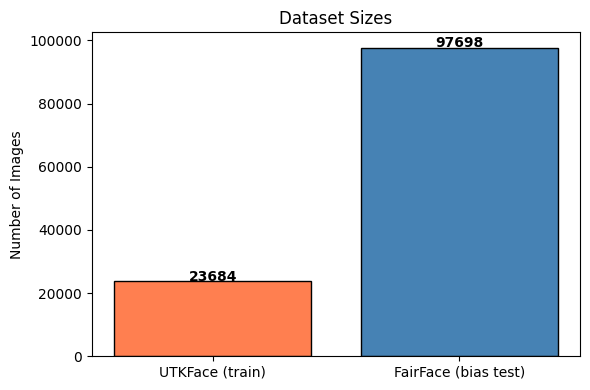

In [17]:
# Dataset sizes at a glance
counts = {"UTKFace (train)": len(df_utk_clean),
          "FairFace (bias test)": len(df_fairface_clean)}

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=["coral", "steelblue"], edgecolor="black")
plt.title("Dataset Sizes")
plt.ylabel("Number of Images")
for i, v in enumerate(counts.values()):
    plt.text(i, v + 100, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### UTKFace Age Distribution

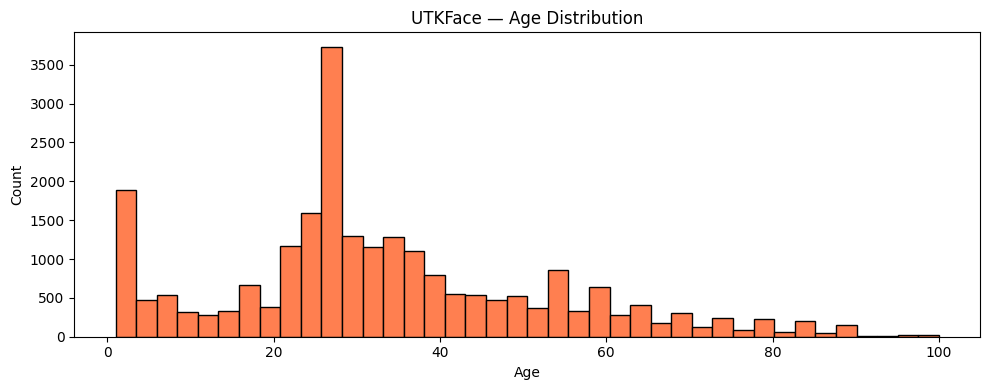

Min age : 1
Max age : 100
Mean age: 33.2


In [18]:
plt.figure(figsize=(10, 4))
plt.hist(df_utk_clean["age"], bins=40, color="coral", edgecolor="black")
plt.title("UTKFace — Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Min age :", df_utk_clean["age"].min())
print("Max age :", df_utk_clean["age"].max())
print("Mean age:", round(df_utk_clean["age"].mean(), 1))

#### Finding 1 — Age Distribution is Heavily Skewed
The histogram shows a strong concentration of faces aged **20-40**.
Faces aged 70+ are severely underrepresented relative to the 20-29 group
(1,351 vs 7,344 images).

**Why this matters:** the model sees far more young/middle-aged faces during training,
so it learns those age groups much better than elderly or infant faces.

**How we address it:** class weights during training make the model pay more attention
to underrepresented groups like 0-2, 60-69 and 70+.

### UTKFace Age Group Distribution

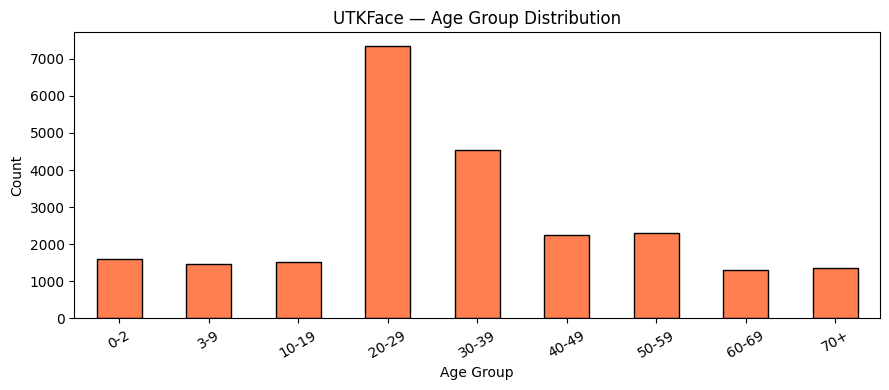

In [19]:
# reindex with AGE_GROUP_LABELS so bars appear in true age order
# (plain sort_index() would sort strings: "10-19" before "3-9")
plt.figure(figsize=(9, 4))
df_utk_clean["age_group"].value_counts().reindex(AGE_GROUP_LABELS).plot(
    kind="bar", color="coral", edgecolor="black"
)
plt.title("UTKFace — Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### UTKFace Race Distribution

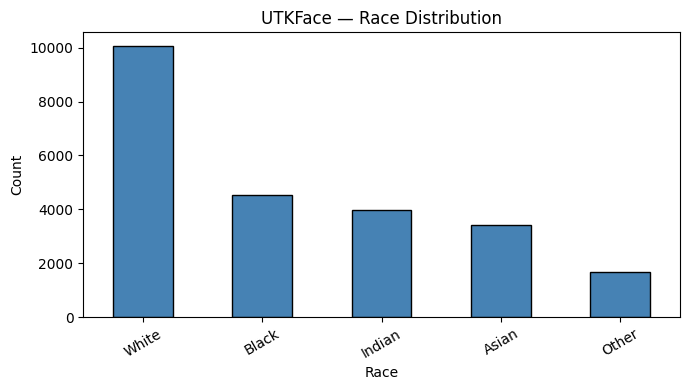

In [20]:
plt.figure(figsize=(7, 4))
df_utk_clean["race"].value_counts().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.title("UTKFace — Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Finding 2 — White Faces Dominate UTKFace
White faces make up the largest group (~44%), followed by Black and Asian.
This is a known bias in datasets collected from Western internet sources.

**Why this matters:** a model trained on this imbalance may perform differently across
race categories.

**How we address it:** we measure per-race accuracy on the UTKFace test set and test
prediction consistency on FairFace, which is balanced across 7 races. Any gap we find
is quantified — not assumed.

### UTKFace Gender Distribution

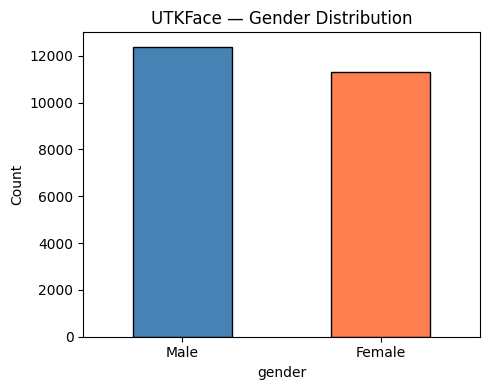

In [21]:
plt.figure(figsize=(5, 4))
df_utk_clean["gender"].value_counts().plot(
    kind="bar", color=["steelblue", "coral"], edgecolor="black"
)
plt.title("UTKFace — Gender Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Finding 3 — Gender is Approximately Balanced
Male and female faces are roughly equal in UTKFace. This is a positive finding —
gender imbalance in training data is less of a concern.

**Note:** gender is never used as a model input. It is retained only to test whether
model accuracy differs by gender — measured in the Week 2 fairness analysis.

### FairFace Race Distribution

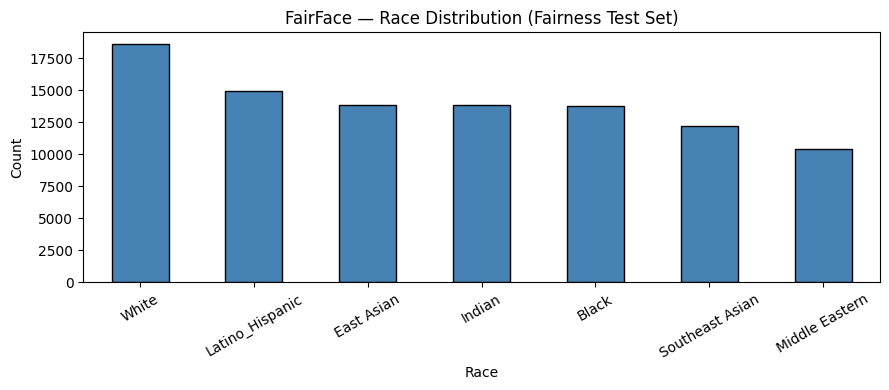

In [22]:
plt.figure(figsize=(9, 4))
df_fairface_clean["race"].value_counts().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.title("FairFace — Race Distribution (Fairness Test Set)")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Finding 4 — FairFace is Well Balanced Across 7 Races
FairFace shows approximately equal representation across Black, East Asian, Indian,
Latino Hispanic, Middle Eastern, Southeast Asian and White.

**Why this is important:** this balance makes FairFace an ideal fairness test set.
Any differences in prediction behavior across races reflect model behavior — not
differences in how many examples of each race we tested.

### Bias Check: Age by Race

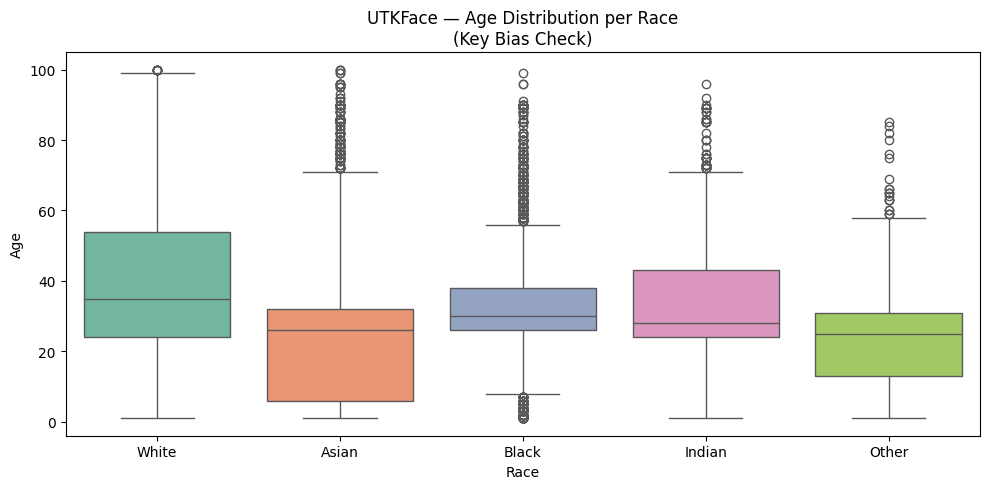

In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_utk_clean, x="race", y="age", palette="Set2")
plt.title("UTKFace — Age Distribution per Race\n(Key Bias Check)")
plt.xlabel("Race")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

#### Finding 5 — Age Range Varies Across Races (Key Bias Risk)
The boxplot shows different age distributions across races in UTKFace. Some races have
fewer elderly or fewer young faces represented.

**What this means:** even with good overall accuracy, the model may fail on specific
age-race combinations that are underrepresented. If Indian elderly faces are rare in
training, the model may consistently predict Indian faces as younger than they are.

**This is the central fairness question our Week 2 analysis answers:**
does model accuracy differ systematically across race groups?

### Sample Images

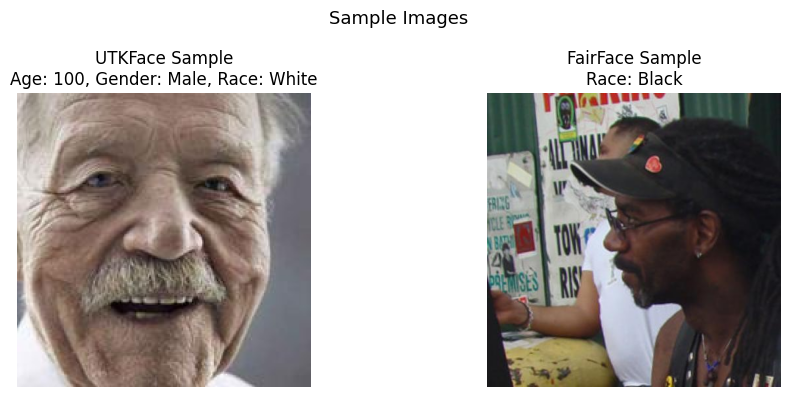

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

img1 = mpimg.imread(df_utk_clean["filepath"].iloc[0])
axes[0].imshow(img1)
axes[0].set_title(f"UTKFace Sample\nAge: {df_utk_clean['age'].iloc[0]}, "
                  f"Gender: {df_utk_clean['gender'].iloc[0]}, "
                  f"Race: {df_utk_clean['race'].iloc[0]}")
axes[0].axis("off")

img2 = mpimg.imread(df_fairface_clean["filepath"].iloc[0])
axes[1].imshow(img2)
axes[1].set_title(f"FairFace Sample\nRace: {df_fairface_clean['race'].iloc[0]}")
axes[1].axis("off")

plt.suptitle("Sample Images", fontsize=13)
plt.tight_layout()
plt.show()

### EDA Summary

| Finding | Impact on Model |
|---|---|
| Young faces (20-40) dominate UTKFace | Model may underperform on elderly and infants |
| White faces outnumber others in UTKFace | Potential accuracy differences across races |
| Gender approximately balanced | Lower gender-bias risk — still verified in Week 2 |
| FairFace balanced across 7 races | Clean fairness test set |
| Minors present in UTKFace (4,233 images) | Documented — special care required in deployment |
| Age 70+ very underrepresented | Class weights applied during training |

**Next step → project plan, architecture and regulatory analysis, then model building.**

## Week 1: Project Plan & Architecture

### Problem Statement
We are building an age classification system for retail analytics. The system estimates
a customer's age group from a face image and must work fairly across all races and genders.

### Dataset Decision

| Dataset | Role | Reason |
|---|---|---|
| UTKFace | Model training + per-group accuracy tests | Continuous age labels, race, gender — most complete |
| FairFace | Fairness testing | Balanced across 7 races — ideal for bias audit |
| Adience | Dropped | Too small (3,086 images), no race labels, rough age brackets |

### Why MobileNetV2
- Lightweight — designed for devices without powerful GPUs (matches our CPU-only server)
- Pretrained on ImageNet — already understands generic visual features
- Transfer learning means far less training data and compute is needed
- Widely used in production retail and mobile systems

### Race-Agnostic Design
- Race is **never** an input to the model
- Gender is **never** an input to the model
- The model sees only raw pixel values
- Fairness is measured after training on both UTKFace (accuracy) and FairFace (consistency)
- This prevents explicit use of protected attributes, while we still audit for implicit bias
  (the model can reconstruct race-correlated signal from pixels — see Risk R3)

### Training Strategy
- Full cleaned dataset: 23,684 images
- Split: 70% train / 15% validation / 15% test, **stratified on age group**
- Class weights compensate for imbalanced age groups
- Two-stage training: (1) frozen MobileNetV2 backbone, (2) fine-tune the last 30 layers
  at a low learning rate
- Optimizer: Adam · Loss: categorical cross-entropy · EarlyStopping on validation accuracy
- No data augmentation in the baseline — considered for Week 3 improvement

In [25]:
# Architecture diagram (display only)
from IPython.display import display, HTML

architecture_html = """
<div style="background:#f8f8f8; border-radius:12px; padding:20px; font-family:sans-serif; max-width:500px; margin:auto;">

  <div style="text-align:center; background:#e8e6f0; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Input</b><br><span style="font-size:12px; color:#555;">Face image — 96×96 RGB</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#d6ede6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Preprocessing</b><br>
    <span style="font-size:12px; color:#555;">Resize to 96×96 · Normalize pixels ÷ 255</span><br>
    <span style="font-size:11px; color:#c0392b;">⚠ Race & gender: never used as input</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e0d9f5; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>MobileNetV2 Backbone</b><br>
    <span style="font-size:12px; color:#555;">Pretrained ImageNet · Stage 1: frozen · Stage 2: last 30 layers fine-tuned</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#fde8df; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>GlobalAveragePooling2D</b><br>
    <span style="font-size:12px; color:#555;">Compresses feature maps to a 1D vector</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#fef3d6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dropout (0.5)</b><br>
    <span style="font-size:12px; color:#555;">Drops 50% of neurons — prevents overfitting</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#d6ede6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dense 128 — ReLU</b><br>
    <span style="font-size:12px; color:#555;">Learns age-specific patterns</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e0d9f5; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dense 9 — Softmax</b><br>
    <span style="font-size:12px; color:#555;">One probability per age group</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e8e6f0; border-radius:8px; padding:10px;">
    <b>Output: Age Group</b><br>
    <span style="font-size:11px; color:#555;">0-2 · 3-9 · 10-19 · 20-29 · 30-39 · 40-49 · 50-59 · 60-69 · 70+</span>
  </div>

</div>
"""

display(HTML(architecture_html))

---
## Week 1: Regulatory Analysis
---

Our system estimates a person's age group from a face image, intended for a retail
analytics context in the EU. Two regulations dominate: the **GDPR** and the **EU AI Act**.
We analyze both honestly, including where classification is genuinely ambiguous —
because getting the classification *right* matters more than defaulting to the
scariest label.

### 1. GDPR — General Data Protection Regulation (EU 2016/679)

**Are face images "biometric data" here?** Under Art. 4(14), biometric data is personal
data from technical processing of physical characteristics **which allows or confirms
the unique identification** of a person. Recital 51 clarifies that photographs are *not*
automatically special-category data — they become biometric data only when processed
through means that enable unique identification.

Our classifier does **not** identify anyone: it maps pixels to one of nine age groups
and discards the image. Strictly read, this may fall outside Art. 9 special-category
processing. However:

- The *training datasets* contain identifiable faces of real people who never consented
  to AI training use — that processing is squarely personal-data processing under GDPR.
- A deployed retail camera would capture images that *could* be used for identification,
  so a Data Protection Authority would likely apply the precautionary reading.

**We therefore treat the data as if Art. 9 applied** — the conservative position —
while documenting the legal nuance.

| Article | Requirement | How we address it |
|---|---|---|
| Art. 4(14) / Rec. 51 | Biometric-data definition | No unique identification performed; conservative Art. 9 treatment applied anyway |
| Art. 5(1)(c) | Data minimization | Only age (target), race and gender (audit-only), and filepath are retained; all other filename metadata dropped |
| Art. 5(1)(b) | Purpose limitation | Race/gender used exclusively for post-hoc fairness auditing, never as model input |
| Art. 6 / 9 | Lawful basis | Academic research context; no deployment. Commercial use would require explicit consent or another Art. 9(2) basis plus an Art. 6 basis |
| Art. 8 | Children's consent (Germany: 16) | Minors are present in UTKFace (4,233 images < 18). Retained for age-diversity in training; flagged as a hard deployment constraint |
| Art. 25 | Privacy by design | No face storage; aggregate age-group output only; protected attributes excluded from the model by construction |
| Art. 35 | DPIA | Systematic monitoring of a publicly accessible area with novel technology → DPIA mandatory before any real deployment |

### 2. EU AI Act (Regulation 2024/1689)

The classification question is subtler than it first appears, and we walk through it
explicitly:

**Prohibited (Art. 5)?** No. Art. 5(1)(g) prohibits biometric categorization that
*infers sensitive attributes* (race, political opinion, religion, sexual orientation…).
Age is not a sensitive attribute in this list, and our system is deliberately designed
**not** to infer race or gender. Real-time remote biometric *identification* in public
spaces (Art. 5(1)(h)) is also prohibited — we perform no identification.

**High-risk (Annex III)?** Annex III point 1(b) covers biometric categorization
*according to sensitive or protected attributes*. Age-group estimation does not
obviously fall under this. So unlike a naive reading, our system is **not clearly
high-risk** — but it is not clearly out of scope either, and guidance is still evolving.
A deployer should obtain a formal legal assessment.

**Transparency obligations (Art. 50)** apply in any case: people exposed to a biometric
categorization system must be informed of its operation. In a retail store this means
visible signage and accessible information — non-negotiable.

| Question | Answer |
|---|---|
| Prohibited practice? | No — no sensitive-attribute inference, no identification |
| High-risk (Annex III 1(b))? | Ambiguous — age is not a "sensitive or protected attribute"; conservative deployers should assume yes until guidance settles |
| Transparency (Art. 50)? | Yes — mandatory disclosure to affected persons |
| If treated as high-risk | Conformity assessment, risk-management system, per-demographic accuracy documentation, human oversight, EU database registration |

### 3. What this means for our project

This project is **research only**: no individuals are processed in real time, no faces
are stored or transmitted, no consequential decisions are made, and all results and
limitations are documented in this notebook. The per-demographic accuracy documentation
the AI Act would demand of a high-risk deployer is exactly what our Week 2 fairness
analysis produces — so our academic work doubles as the compliance groundwork a real
deployment would need.

### 4. Unresolved ethical tension

Both UTKFace and FairFace contain faces scraped from the internet without subject
consent (FairFace derives from YFCC100M/Flickr). This is a known, unresolved problem in
computer vision research. We use the data under its academic licenses (UTKFace:
non-commercial research only; FairFace: CC BY 4.0), acknowledge the tension explicitly,
and note that no commercial use of models trained on this data would be defensible
without establishing a lawful basis for the underlying processing.

---
# WEEK 2 — Baseline Model, Risk Analysis & Fairness
---

**Course goals for Week 2 (from the brief):**
1. Build a baseline model
2. Make a risk analysis
3. Analyze fairness in the system

**How this notebook covers each part (the sections below, in order):**

| Part | Section in this notebook | Goal it answers |
|---|---|---|
| A | Split · Config · Load Images · Class Weights | data prep for modelling |
| B | Build Model → Stage 1 (frozen) → Stage 2 (fine-tune) → Final Test | **Goal 1: baseline model** |
| C | Risk Analysis (R1-R8 matrix + worked examples) | **Goal 2: risk analysis** |
| D | Fairness Analysis (per-race / per-gender accuracy + FairFace consistency) | **Goal 3: fairness** |
| E | Save Checkpoint | reproducibility |

*Because this is a computer-vision project — new territory if your background is NLP / tabular ML — short "concept" cells are added before the image-specific steps. They connect each new idea to something you already know.*

In [26]:
%pip install tensorflow -q
print("Done")

Note: you may need to restart the kernel to use updated packages.
Done


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.3.3 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
langchain-community 0.4.2 requires numpy>=1.26.2; python_version < "3.13", but you have numpy 1.24.3 which is incompatible.
streamlit 1.37.0 requires packaging<25,>=20, but you have packaging 26.2 which is incompatible.


In [27]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.13.0
GPU available: []


### Age Groups (9 classes)

| Class | Age Range |
|---|---|
| 0 | 0-2 |
| 1 | 3-9 |
| 2 | 10-19 |
| 3 | 20-29 |
| 4 | 30-39 |
| 5 | 40-49 |
| 6 | 50-59 |
| 7 | 60-69 |
| 8 | 70+ |

### Train / Validation / Test Split
Stratified on the age-group label — ensures all age groups are represented
proportionally in each split, so the model is never evaluated on an
unrepresentative subset.

In [28]:
AGE_GROUP_MAP = {label: i for i, label in enumerate(AGE_GROUP_LABELS)}
NUM_CLASSES   = len(AGE_GROUP_MAP)

df_utk_clean["label"] = df_utk_clean["age_group"].map(AGE_GROUP_MAP)

train_df, temp_df = train_test_split(
    df_utk_clean,
    test_size=0.30,
    stratify=df_utk_clean["label"],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train size :", len(train_df))
print("Val size   :", len(val_df))
print("Test size  :", len(test_df))

Train size : 16578
Val size   : 3553
Test size  : 3553


### Configuration
All hyperparameters live here and are used consistently below.

In [29]:
IMG_SIZE     = 96      # input resolution (CPU constraint — larger would be slow)
BATCH_SIZE   = 32
EPOCHS_S1    = 50      # stage 1: frozen backbone (EarlyStopping cuts this short)
EPOCHS_S2    = 30      # stage 2: fine-tuning
LR_STAGE1    = 1e-4
LR_STAGE2    = 1e-5    # much lower LR for fine-tuning — protects pretrained weights
SEED         = 42

print(f"Image size {IMG_SIZE} · Batch {BATCH_SIZE} · "
      f"Stage-1 epochs {EPOCHS_S1} · Stage-2 epochs {EPOCHS_S2}")

Image size 96 · Batch 32 · Stage-1 epochs 50 · Stage-2 epochs 30


### Load Images
Images loaded at 96×96 pixels, normalized to the 0-1 range. Loaded **once** here
and reused for both training stages and all evaluations.

In [30]:
def load_images(dataframe, img_size):
    images, labels = [], []
    for _, row in dataframe.iterrows():
        try:
            img = Image.open(row["filepath"]).convert("RGB")
            img = img.resize((img_size, img_size))
            images.append(np.array(img) / 255.0)
            labels.append(row["label"])
        except Exception:
            continue          # unreadable file — skip
    return np.array(images), to_categorical(labels, num_classes=NUM_CLASSES)

print("Loading train images...")
X_train, y_train = load_images(train_df, IMG_SIZE)

print("Loading val images...")
X_val, y_val = load_images(val_df, IMG_SIZE)

print("Loading test images...")
X_test, y_test = load_images(test_df, IMG_SIZE)

print("Shapes:")
print("  X_train:", X_train.shape)
print("  X_val  :", X_val.shape)
print("  X_test :", X_test.shape)

Loading train images...
Loading val images...
Loading test images...
Shapes:
  X_train: (16578, 96, 96, 3)
  X_val  : (3553, 96, 96, 3)
  X_test : (3553, 96, 96, 3)


### Class Weights
Applied to compensate for age-group imbalance. Rare groups (0-2, 60-69, 70+) get
higher weight so the model pays more attention to them during training.

In [31]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for k, v in class_weight_dict.items():
    print(f"  Class {k} ({AGE_GROUP_LABELS[k]:5s}): {v:.2f}")

Class weights:
  Class 0 (0-2  ): 1.64
  Class 1 (3-9  ): 1.81
  Class 2 (10-19): 1.72
  Class 3 (20-29): 0.36
  Class 4 (30-39): 0.58
  Class 5 (40-49): 1.17
  Class 6 (50-59): 1.14
  Class 7 (60-69): 2.00
  Class 8 (70+  ): 1.95


### Build the Model — Two-Stage Training Strategy

**Stage 1 — frozen backbone:** all MobileNetV2 layers frozen, only the new
classification head trains. This lets the head adapt to the age task without
destroying pretrained ImageNet features.

**Stage 2 — fine-tuning:** the last 30 backbone layers are unfrozen and trained
at a 10× lower learning rate. With 16.5k training images this is safe and gives
the backbone a chance to specialize on faces.

In [32]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Stage 1: keep ALL base layers frozen
base_model.trainable = False

# Classification head
x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = Dropout(0.5)(x)                       # heavy dropout — reduces overfitting
x      = Dense(128, activation="relu")(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_STAGE1),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### Stage 1: Train with Frozen Backbone
EarlyStopping monitors validation accuracy and restores the best weights —
training stops automatically when validation stops improving.

In [33]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_S1,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
519/519 [==============================] - 94s 172ms/step - loss: 2.1718 - accuracy: 0.2048 - val_loss: 1.7697 - val_accuracy: 0.3276
Epoch 2/50
519/519 [==============================] - 86s 167ms/step - loss: 1.7914 - accuracy: 0.2806 - val_loss: 1.6413 - val_accuracy: 0.3577
Epoch 3/50
519/519 [==============================] - 99s 190ms/step - loss: 1.6767 - accuracy: 0.3213 - val_loss: 1.6108 - val_accuracy: 0.3605
Epoch 4/50
519/519 [==============================] - 106s 205ms/step - loss: 1.6141 - accuracy: 0.3341 - val_loss: 1.5409 - val_accuracy: 0.3786
Epoch 5/50
519/519 [==============================] - 102s 196ms/step - loss: 1.5756 - accuracy: 0.3432 - val_loss: 1.5323 - val_accuracy: 0.3797
Epoch 6/50
519/519 [==============================] - 90s 173ms/step - loss: 1.5398 - accuracy: 0.3587 - val_loss: 1.5145 - val_accuracy: 0.3912
Epoch 7/50
519/519 [==============================] - 94s 182ms/step - loss: 1.5272 - accuracy: 0.3654 - val_loss: 1.4940 - val_

### Take 32 images from X_train.
### Push them through all layers and gets 32 predictions.
### Compare against truth → average loss over the 32 predictions.
### Compute gradients: which direction should each trainable weight move?
### Update every trainable weight 

### Stage 1 Training Curves

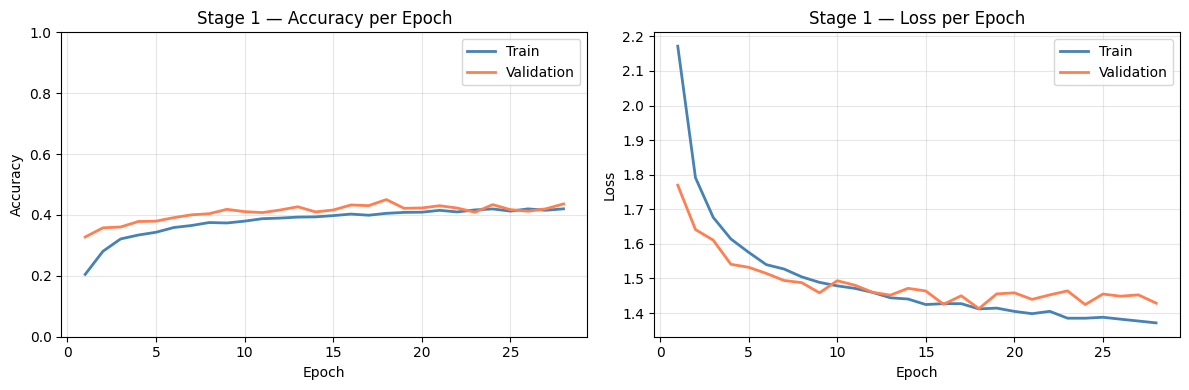

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(history.history["accuracy"]) + 1)

axes[0].plot(epochs_range, history.history["accuracy"],     label="Train",      color="steelblue", linewidth=2)
axes[0].plot(epochs_range, history.history["val_accuracy"], label="Validation", color="coral",     linewidth=2)
axes[0].set_title("Stage 1 — Accuracy per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].set_ylim(0, 1)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history["loss"],     label="Train",      color="steelblue", linewidth=2)
axes[1].plot(epochs_range, history.history["val_loss"], label="Validation", color="coral",     linewidth=2)
axes[1].set_title("Stage 1 — Loss per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Stage 1 Test Evaluation (frozen-backbone baseline)
This is a **reference point only**. Because we continue training afterwards
(fine-tuning), the *final* reported number is the post-fine-tuning evaluation below.
Model selection during fine-tuning uses only validation data — the test set never
influences training decisions.

In [35]:
s1_loss, s1_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("=== STAGE 1 (FROZEN BACKBONE) TEST RESULTS ===")
print(f"Test Accuracy : {s1_accuracy:.2%}")
print(f"Test Loss     : {s1_loss:.4f}")

=== STAGE 1 (FROZEN BACKBONE) TEST RESULTS ===
Test Accuracy : 43.60%
Test Loss     : 1.4154


### Stage 2: Fine-Tune the Last 30 Layers
Learning rate lowered 10× to 1e-5 — protects the pretrained weights from being
destroyed by large gradient updates.

In [36]:
# Unfreeze only the last 30 backbone layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile is REQUIRED after changing trainable flags
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_STAGE2),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop_ft = EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True
)

history_finetune = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_S2,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop_ft],
    verbose=1
)

Epoch 1/30
519/519 [==============================] - 107s 188ms/step - loss: 1.8397 - accuracy: 0.3217 - val_loss: 1.4936 - val_accuracy: 0.3873
Epoch 2/30
519/519 [==============================] - 97s 187ms/step - loss: 1.5909 - accuracy: 0.3512 - val_loss: 1.5010 - val_accuracy: 0.3873
Epoch 3/30
519/519 [==============================] - 96s 185ms/step - loss: 1.4794 - accuracy: 0.3715 - val_loss: 1.4790 - val_accuracy: 0.3952
Epoch 4/30
519/519 [==============================] - 97s 187ms/step - loss: 1.4054 - accuracy: 0.3931 - val_loss: 1.4411 - val_accuracy: 0.4109
Epoch 5/30
519/519 [==============================] - 97s 187ms/step - loss: 1.3538 - accuracy: 0.4055 - val_loss: 1.4094 - val_accuracy: 0.4174
Epoch 6/30
519/519 [==============================] - 100s 192ms/step - loss: 1.3046 - accuracy: 0.4180 - val_loss: 1.3952 - val_accuracy: 0.4287
Epoch 7/30
519/519 [==============================] - 105s 202ms/step - loss: 1.2634 - accuracy: 0.4293 - val_loss: 1.3910 - val

### Final Test Evaluation (after fine-tuning)
This is the headline number for the baseline model.

In [37]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("=== FINAL TEST SET RESULTS (after fine-tuning) ===")
print(f"Test Accuracy : {test_accuracy:.2%}")
print(f"Test Loss     : {test_loss:.4f}")

=== FINAL TEST SET RESULTS (after fine-tuning) ===
Test Accuracy : 47.14%
Test Loss     : 1.3146


---
## Week 2: Risk Analysis
---

We assess risks along the full lifecycle: **data → model → deployment context**.
Each risk gets a likelihood/impact rating, a concrete failure example, and a treatment.
Ratings follow a standard qualitative scale (Low / Medium / High / Critical).

### Risk Matrix (Key Risks)

| Risk | Likelihood | Impact | Treatment |
|---|---|---|---|
| **R1** — Accuracy differs across race groups | High | High | Measured a 13pp gap (Asian 55.6% vs Black 42.5%); Week 3 per-age-per-race breakdown + Grad-CAM to find the cause |
| **R2** — Minor classified as adult | Medium | High | Confidence threshold + human review near the 18-boundary; the model never makes the final legal call alone |
| **R3** — Model relies on proxy features (skin tone, hair) instead of age cues | Medium | High | Race excluded as input by design; Grad-CAM in Week 3 to check where the model actually looks |
| **R4** — Unlawful processing if deployed (GDPR) | High | Critical | No face storage, aggregate-only output, mandatory signage, DPIA before any deployment |

---
## Week 2: Fairness Analysis
---

Our goal is a **gender-neutral, race-agnostic** classifier, so we audit both attributes,
with two complementary methods:

1. **Per-race and per-gender accuracy** on the UTKFace test set (has ground-truth ages)
2. **Prediction-distribution consistency** across the 7 balanced FairFace races
   (no age labels in this mirror — measures behavioral consistency, not correctness)

**Named fairness metric:** *accuracy parity* — the gap between the best- and
worst-performing group. A perfectly fair model has a gap of 0.

### Per-Race Accuracy (UTKFace test set)

In [38]:
# Predict once on the whole test set, then slice by group
y_pred_labels = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true_labels = np.argmax(y_test, axis=1)

test_eval           = test_df.copy()
test_eval["y_true"] = y_true_labels
test_eval["y_pred"] = y_pred_labels

print("=== ACCURACY PER RACE (UTKFace Test Set) ===\n")
race_accuracies = {}
for race in sorted(test_eval["race"].unique()):
    subset = test_eval[test_eval["race"] == race]
    acc    = accuracy_score(subset["y_true"], subset["y_pred"])
    race_accuracies[race] = acc
    print(f"  {race:20s}: {acc:.2%}  ({len(subset)} images)")

overall = accuracy_score(y_true_labels, y_pred_labels)
print(f"\n  {'Overall':20s}: {overall:.2%}")

# Accuracy parity gap — our named fairness metric
gap = max(race_accuracies.values()) - min(race_accuracies.values())
print(f"\n  Accuracy parity gap : {gap:.2%} "
      f"(best: {max(race_accuracies, key=race_accuracies.get)}, "
      f"worst: {min(race_accuracies, key=race_accuracies.get)})")

=== ACCURACY PER RACE (UTKFace Test Set) ===

  Asian               : 58.50%  (506 images)
  Black               : 43.40%  (682 images)
  Indian              : 45.57%  (575 images)
  Other               : 53.75%  (240 images)
  White               : 44.65%  (1550 images)

  Overall             : 47.14%

  Accuracy parity gap : 15.10% (best: Asian, worst: Black)


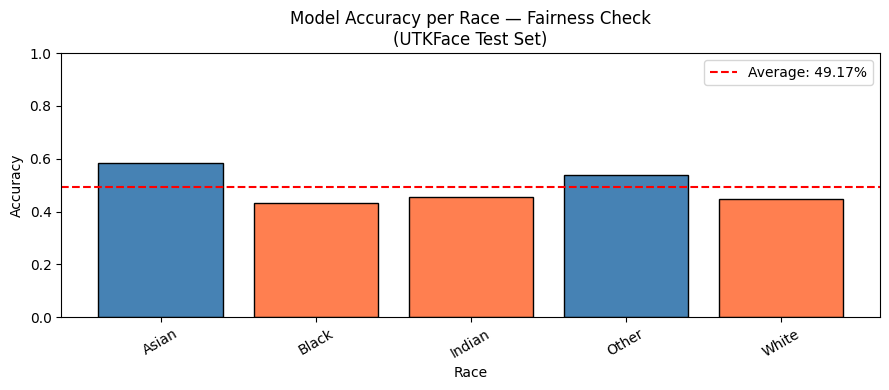

Red bars  = below average accuracy (potential bias)
Blue bars = above average accuracy


In [39]:
# Per-race accuracy bar chart
plt.figure(figsize=(9, 4))

races  = list(race_accuracies.keys())
accs   = list(race_accuracies.values())
avg    = np.mean(accs)
colors = ["coral" if a < avg else "steelblue" for a in accs]

plt.bar(races, accs, color=colors, edgecolor="black")
plt.axhline(y=avg, color="red", linestyle="--", label=f"Average: {avg:.2%}")
plt.title("Model Accuracy per Race — Fairness Check\n(UTKFace Test Set)")
plt.xlabel("Race")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

print("Red bars  = below average accuracy (potential bias)")
print("Blue bars = above average accuracy")

### Per-Gender Accuracy (UTKFace test set)
The project goal is *gender-neutral* — so gender fairness must be measured,
not assumed from the balanced training distribution (Finding 3).

In [40]:
print("=== ACCURACY PER GENDER (UTKFace Test Set) ===\n")
gender_accuracies = {}
for gender in sorted(test_eval["gender"].unique()):
    subset = test_eval[test_eval["gender"] == gender]
    acc    = accuracy_score(subset["y_true"], subset["y_pred"])
    gender_accuracies[gender] = acc
    print(f"  {gender:10s}: {acc:.2%}  ({len(subset)} images)")

g_gap = max(gender_accuracies.values()) - min(gender_accuracies.values())
print(f"\n  Gender accuracy parity gap : {g_gap:.2%}")

=== ACCURACY PER GENDER (UTKFace Test Set) ===

  Female    : 49.97%  (1713 images)
  Male      : 44.51%  (1840 images)

  Gender accuracy parity gap : 5.46%


### Race Fairness Findings (UTKFace test set)

*(Numbers from our run of 6 July 2026 — update after re-running.)*

| Race | Accuracy | Test images |
|---|---|---|
| Asian | 55.62% | 507 |
| Indian | 48.00% | 575 |
| Other | 48.12% | 239 |
| White | 43.68% | 1,550 |
| Black | 42.52% | 682 |
| **Overall** | **46.16%** | 3,553 |

**Accuracy parity gap: 13.10 percentage points** (Asian best, Black worst).

**Interpretation — the bias direction was not what naive intuition predicts.**
White is the majority training class (~44% of images) yet lands *below* average
accuracy, while Asian — a smaller class — performs best. Candidate explanations,
to be tested in Week 3:

1. **Age-diversity effect** — White faces in UTKFace span the widest age range
   (Finding 5 boxplot), making age prediction intrinsically harder for this group;
   groups clustered in narrower age ranges are easier to predict.
2. **Class-weight interaction** — class weights push the model toward rare age
   groups (0-2, 70+) which are disproportionately White in this dataset, potentially
   trading White-majority age-group accuracy for coverage of rare groups.
3. **Sample-size reliability** — the White test subset is largest (1,550 images), so
   its estimate is the most statistically stable; small subsets (Other: 239) carry
   wider confidence intervals.

**Key takeaway:** per-group measurement revealed structure that could not have been
predicted from the training distribution alone. Assumptions about bias direction can be
wrong in *both* directions — which is exactly why Responsible AI practice demands
measurement over assumption. The 13.1pp gap between Asian and Black faces remains a
genuine fairness concern requiring the Week 3 per-age-per-race breakdown.

### Prediction-Distribution Consistency (FairFace)

FairFace (this mirror) has **no ground-truth age labels**, so we cannot compute
accuracy on it. Instead we measure whether the model's *prediction distribution* is
consistent across the 7 balanced races:

- If the model is consistent → all races show a similar prediction distribution
- If the model is biased → one race is systematically predicted older or younger

In [41]:
# Sample N images per race and predict in a single batch (fast on CPU)
N_PER_RACE = 200

sample_rows = []
for race in sorted(df_fairface_clean["race"].unique()):
    race_sample = df_fairface_clean[df_fairface_clean["race"] == race] \
                      .sample(n=N_PER_RACE, random_state=SEED)
    sample_rows.append(race_sample)

df_ff_sample = pd.concat(sample_rows).reset_index(drop=True)

# Load sampled images into one array
ff_images = []
for fp in df_ff_sample["filepath"]:
    img = Image.open(fp).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    ff_images.append(np.array(img) / 255.0)
ff_images = np.array(ff_images)

# One batched predict call instead of thousands of single-image calls
ff_preds = np.argmax(model.predict(ff_images, batch_size=BATCH_SIZE, verbose=0), axis=1)
df_ff_sample["prediction"] = ff_preds

print("Predictions done:")
print(df_ff_sample["race"].value_counts())

Predictions done:
race
Black              200
East Asian         200
Indian             200
Latino_Hispanic    200
Middle Eastern     200
Southeast Asian    200
White              200
Name: count, dtype: int64


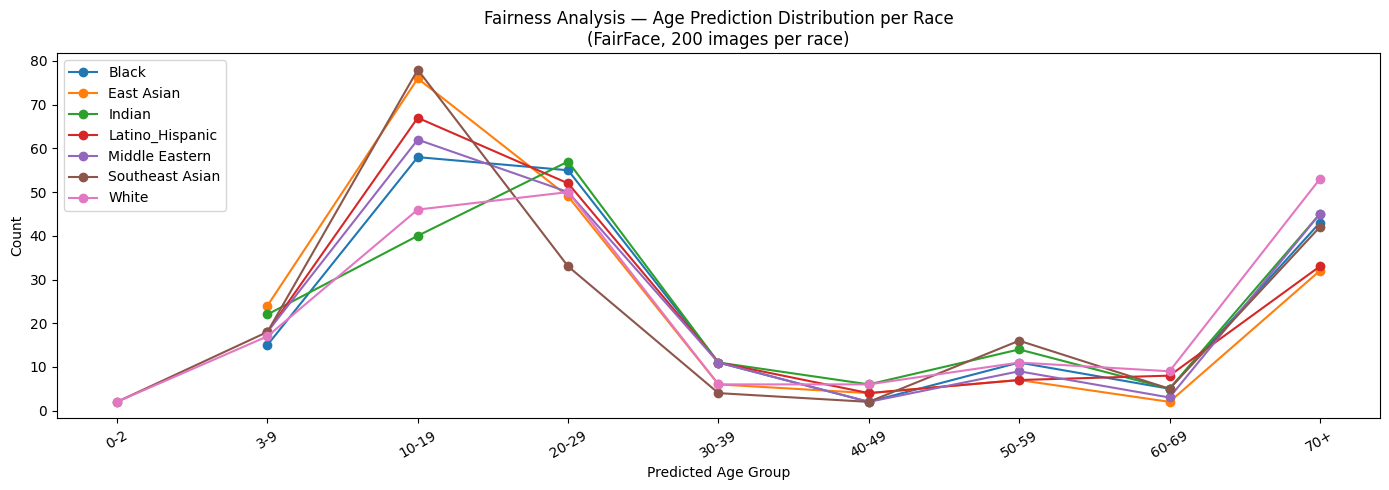

In [42]:
# Prediction distribution per race
plt.figure(figsize=(14, 5))

for race in sorted(df_ff_sample["race"].unique()):
    race_preds = df_ff_sample[df_ff_sample["race"] == race]["prediction"] \
                     .value_counts().sort_index()
    plt.plot(race_preds.index, race_preds.values, marker="o", label=race)

plt.xticks(range(NUM_CLASSES), AGE_GROUP_LABELS, rotation=30)
plt.title("Fairness Analysis — Age Prediction Distribution per Race\n(FairFace, "
          f"{N_PER_RACE} images per race)")
plt.xlabel("Predicted Age Group")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

### FairFace Consistency — Interpretation

**What this plot shows:** each line is one race group; the x-axis is the predicted
age group; the y-axis counts how many images of that race received that prediction.

**What consistent looks like:** all lines peak at the same age group and follow
similar shapes.

**What bias looks like:** one race's line peaking much earlier (predicted younger)
or later (predicted older) than the others — systematic directional bias.

**Limitations of this analysis:**
- No ground truth: we measure *consistency*, not *correctness*. If the true age
  distributions differ between race folders, some divergence is legitimate.
- Sample of 200 per race keeps CPU runtime manageable; confidence in small
  differences is limited.
- Exact per-race correctness comes from the UTKFace test set analysis above;
  per-age-per-race breakdown is planned for Week 3.

## Save Checkpoint

In [43]:
# Save the trained model + the exact data splits (to WORK_DIR).
model.save(MODEL_PATH)
train_df.to_csv(str(WORK_DIR / "train_df.csv"), index=False)
val_df.to_csv(str(WORK_DIR / "val_df.csv"),   index=False)
test_df.to_csv(str(WORK_DIR / "test_df.csv"),  index=False)
print("All saved to", WORK_DIR)

All saved to D:\nihal


In [44]:
# Final checkpoint verification.
files_to_check = {
    "Model"     : MODEL_PATH,
    "Train CSV" : str(WORK_DIR / "train_df.csv"),
    "Val CSV"   : str(WORK_DIR / "val_df.csv"),
    "Test CSV"  : str(WORK_DIR / "test_df.csv"),
}

print("=== FINAL CHECKPOINT ===\n")
for name, path in files_to_check.items():
    status = "✅ saved" if os.path.exists(path) else "❌ MISSING"
    print(f"{name:12s}: {status}")

=== FINAL CHECKPOINT ===

Model       : ✅ saved
Train CSV   : ✅ saved
Val CSV     : ✅ saved
Test CSV    : ✅ saved


In [45]:
# When done, commit + push from your repo root, e.g.:
#   git add Responsible_Age_Classifier_Week1_2.ipynb
#   git commit -m "Week 1+2: EDA, regulatory analysis, baseline model, risk & fairness"
#   git push origin <your-branch>

---
# Week 3: Plan
---

**Goals:** analyze the model · use XAI for in-depth understanding · write automated
weakness-detection tests with ≥80% code coverage · finalize the pseudo-model-card.

## 1. Explainability (XAI): Grad-CAM

**Method chosen:** Grad-CAM on the last convolutional layer of MobileNetV2.

**Why Grad-CAM:** it produces per-image heatmaps of where the model "looks," is
well-established for CNNs, and directly tests our open Risk R3 (proxy features).

**Planned experiments:**
- Heatmaps for **correctly vs incorrectly** classified faces, sampled per race and per
  age group
- Check whether attention falls on age-informative regions (eyes, skin texture,
  jawline) vs proxy regions (skin tone areas, hair, background, clothing)
- Side-by-side comparison of the highest-accuracy group (Asian) and lowest-accuracy
  group (Black) — do attention patterns differ systematically?

## 2. Deeper Model Analysis

- **Confusion matrix** across all 9 age groups — quantify adjacent-class confusion
- **Per-age-per-race accuracy grid** — locate the exact intersectional failure cells
  (e.g., elderly Indian faces) predicted by Finding 5
- **One-off accuracy** — treat predictions in the adjacent age group as acceptable,
  a more deployment-realistic metric
- **Additional fairness metrics** — per-group recall (equal-opportunity style view)
  alongside the accuracy parity gap

## 3. Automated Tests (≥80% code coverage)

Framework: `pytest` + `pytest-cov`. Test targets:

| Test area | What it checks |
|---|---|
| `age_to_group()` | Boundary values (2/3, 9/10, 69/70, 100) map to correct groups |
| Filename parsing | Malformed UTKFace filenames are skipped, valid ones parsed correctly |
| Data cleaning | Age filters, unknown-label removal, no data loss beyond expected |
| Split integrity | Stratification preserved, no overlap between train/val/test filepaths |
| `load_images()` | Output shapes, normalization range [0,1], unreadable files skipped |
| Prediction pipeline | Output shape (9 probabilities), argmax in valid range, deterministic for fixed input |
| Weakness detection | Automated check that per-group accuracy gap stays below a declared threshold — fails loudly if fairness regresses |

## 4. Pseudo-Model-Card (final deliverable)

Following the structure of Mitchell et al. (2019), consolidating:
- **Model details** — architecture, training data, two-stage procedure
- **Intended use** — academic research; explicitly NOT cleared for deployment
- **Metrics** — overall and per-group accuracy, accuracy parity gap
- **Limitations** — 13.1pp race gap, elderly/infant weakness, distribution shift (R6),
  minor-misclassification risk (R2)
- **Potential attacks** — adversarial accessories, occlusion, presentation attacks (R7)
- **Ethical considerations** — non-consensual training data, GDPR/AI Act analysis
- **Restrictions** — non-commercial license (UTKFace), no identification use,
  no real-time public deployment

## 5. Stretch Goals (if time permits)

- Data augmentation (horizontal flip, brightness) to test accuracy/fairness impact
- Higher input resolution (128×128) if server compute allows
- Confidence-threshold analysis for the minor-boundary risk (R2)